In [2]:
# load the features
import numpy as np
alexnet_fvs = np.load("outputs/alexnet_pooled_features.npy", allow_pickle=True)[:5]
vgg_fvs = np.load("outputs/vgg16_pooled_features.npy", allow_pickle=True)
resnet_fvs = np.load("outputs/resnet50_pooled_features.npy", allow_pickle=True)

print("AlexNet features shape:", alexnet_fvs.shape)
print("VGG features shape:", vgg_fvs.shape)
print("ResNet features shape:", resnet_fvs.shape)

AlexNet features shape: (5,)
VGG features shape: (5,)
ResNet features shape: (5,)


In [3]:
# print the feature shape at each layer
print("\nAlexNet pooled features at each block:")
for bi, feat in enumerate(alexnet_fvs, 1):
    print(f"Block {bi:02d}: shape={feat.shape}")

print("\nVGG16 pooled features at each block:")
for bi, feat in enumerate(vgg_fvs, 1):
    print(f"Block {bi:02d}: shape={feat.shape}")

print("\nResNet50 pooled features at each block:")
for bi, feat in enumerate(resnet_fvs, 1):
    print(f"Block {bi:02d}: shape={feat.shape}")



AlexNet pooled features at each block:
Block 01: shape=(32, 64)
Block 02: shape=(32, 192)
Block 03: shape=(32, 384)
Block 04: shape=(32, 256)
Block 05: shape=(32, 256)

VGG16 pooled features at each block:
Block 01: shape=(32, 64)
Block 02: shape=(32, 128)
Block 03: shape=(32, 256)
Block 04: shape=(32, 512)
Block 05: shape=(32, 512)

ResNet50 pooled features at each block:
Block 01: shape=(32, 64)
Block 02: shape=(32, 256)
Block 03: shape=(32, 512)
Block 04: shape=(32, 1024)
Block 05: shape=(32, 2048)


In [4]:
# insert path to the utils
import sys
sys.path.append("../utils")
import util


alexnet_rep_mat = util.compute_model_rep_mtx(alexnet_fvs)
vgg_rep_mat = util.compute_model_rep_mtx(vgg_fvs)
resnet_rep_mat = util.compute_model_rep_mtx(resnet_fvs)

alexnet_invar_pair = util.compute_pair_inv_model(alexnet_rep_mat)
vgg_invar_pair = util.compute_pair_inv_model(vgg_rep_mat)
resnet_invar_pair = util.compute_pair_inv_model(resnet_rep_mat)

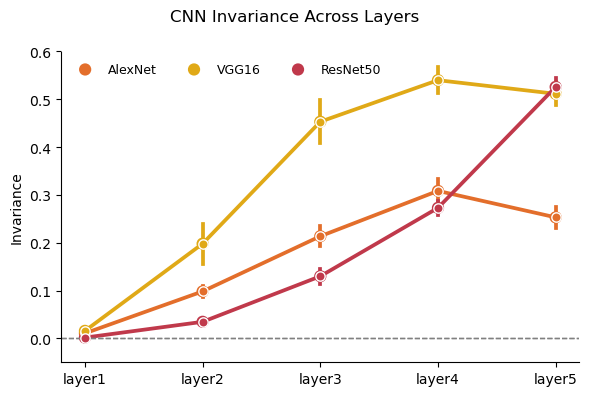

In [11]:
# Define models and their properties
import matplotlib.pyplot as plt
import seaborn as sns

models = [
    {'data': alexnet_invar_pair, 'color': '#e36e2b', 'label': 'AlexNet'},
    {'data': vgg_invar_pair, 'color': '#e0a917', 'label': 'VGG16'},
    {'data': resnet_invar_pair, 'color': '#c0394b', 'label': 'ResNet50'},
]


fig, ax = plt.subplots(figsize=(6, 4))
for model in models:
    points = sns.pointplot(
        x="layer", y="pair_invariance",
        data=model['data'],
        color=model['color'],
        dodge=0, 
        errorbar='se', join=True, linestyles='-', ax=ax,
        label=model['label']
    )
    xvals = np.arange(model['data']['layer'].nunique())
    means = model['data'].groupby('layer')['pair_invariance'].mean().values
    ax.scatter(
        xvals, means,
        color=model['color'], edgecolor='white', s=45, zorder=3
    )

ax.axhline(0, color='gray', lw=1, linestyle='--')
ax.set_xlabel("")
ax.set_ylabel("Invariance")
ax.set_xlabel("Layer")
ax.set_ylim(-0.05, 0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, ncol=3, fontsize=9)

ax.axhline(0, color='gray', lw=1, linestyle='--')
ax.set_xticks([0, 1, 2, 3, 4])
ax.set_xticklabels(['layer1', 'layer2', 'layer3', 'layer4', 'layer5'])
ax.set_xlabel("")
plt.suptitle("CNN Invariance Across Layers")
plt.tight_layout()
plt.savefig("../figures/cnn_invariance.png", dpi=300, bbox_inches='tight')
plt.show()